# Predicting Whether an MLB Game Will Have 9 or More Runs

## Problem Definition

For this project, I wanted to see if I could predict whether an MLB game would have 9 or more total runs. My target variable is `runs_9_plus`, where 1 means the game finished with 9 or more runs and 0 means it finished with less than 9 runs.

This is a classification problem because there are only two possible outcomes. I chose this topic because scoring is a big part of baseball, and I wanted to see if basic pregame information could help predict whether a game would be high scoring or not.

This type of model could be useful for baseball analysts or fans who want to understand what factors might be connected to higher scoring games.

## Background and Context

There are a lot of things that can affect how many runs are scored in an MLB game. One factor is temperature. Research has found that MLB games played in warmer weather tend to have more runs and more home runs than games played in colder weather (Koch & Panorska, 2013).

The ballpark can also matter because every MLB stadium is different. MLB Statcast uses park factors to show how certain stadiums can increase or decrease things like runs and home runs compared to an average ballpark (Major League Baseball, n.d.).

Weather and the environment can also change how the baseball travels. FanGraphs has explained that things like temperature, altitude, wind, and air density can affect how far a batted ball travels, which can also affect scoring (Oler, 2025).

These ideas are why I decided to include venue, weather, and temperature as some of the features in my model.

## Data Description

The dataset I used contains 2,464 MLB games from the 2025 season. Each row represents one game. The data includes the home and away teams, venue, final score, hits, errors, weather, temperature, attendance, and game length. The dataset came from a publicly available 2025 MLB season dataset that was collected from MLB game data.

For this project, my target variable is `runs_9_plus`, which I created from the final score. A value of 1 means the game had 9 or more total runs, and a value of 0 means it had less than 9 runs.

For the model, I used the home team, away team, venue, weather, and temperature as features because these are all things that can be known before the game starts.

Dataset: https://github.com/buuvin/2025-MLB-Season

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv("game_details_2025.csv")
df.head()

,gamePk,date,venue,home_team,away_team,home_team_id,away_team_id,home_score,away_score,home_hits,away_hits,home_errors,away_errors,weather,temperature,attendance,duration_minutes
0,778563,2025-03-18,Tokyo Dome,Chicago Cubs,Los Angeles Dodgers,112,119,1,4,3,7,2,0,Dome,72,42365,158
1,778564,2025-03-19,Tokyo Dome,Chicago Cubs,Los Angeles Dodgers,112,119,3,6,8,7,0,0,Dome,72,42367,165
2,778557,2025-03-27,Yankee Stadium,New York Yankees,Milwaukee Brewers,147,158,4,2,7,7,0,1,Sunny,48,46208,188
3,778556,2025-03-27,Rogers Centre,Toronto Blue Jays,Baltimore Orioles,141,110,2,12,4,14,0,0,Roof Closed,68,40734,169
4,778553,2025-03-27,Globe Life Field,Texas Rangers,Boston Red Sox,140,111,2,5,7,6,0,0,Roof Closed,74,37585,154


In [29]:
print(df.shape)
print(df.columns.tolist())

(2464, 17)
['gamePk', 'date', 'venue', 'home_team', 'away_team', 'home_team_id', 'away_team_id', 'home_score', 'away_score', 'home_hits', 'away_hits', 'home_errors', 'away_errors', 'weather', 'temperature', 'attendance', 'duration_minutes']


In [30]:
df["total_runs"] = df["home_score"] + df["away_score"]

df["runs_9_plus"] = (df["total_runs"] >= 9).astype(int)

df[["home_score", "away_score", "total_runs", "runs_9_plus"]].head()

,home_score,away_score,total_runs,runs_9_plus
0,1,4,5,0
1,3,6,9,1
2,4,2,6,0
3,2,12,14,1
4,2,5,7,0


In [31]:
df["runs_9_plus"].value_counts()

runs_9_plus
0    1259
1    1205
Name: count, dtype: int64

In [32]:
df["runs_9_plus"].value_counts(normalize=True)

runs_9_plus
0    0.510958
1    0.489042
Name: proportion, dtype: float64

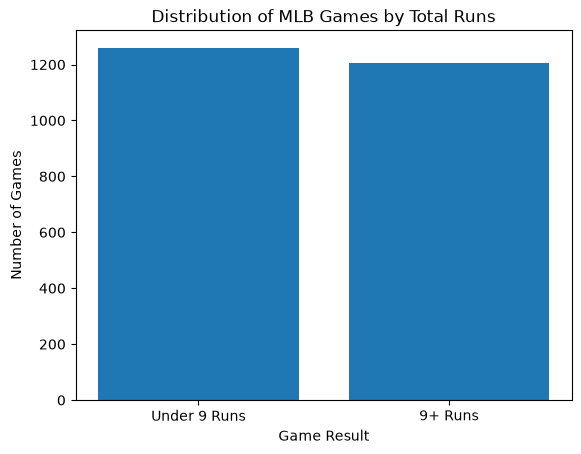

In [33]:
counts = df["runs_9_plus"].value_counts().sort_index()

plt.bar(["Under 9 Runs", "9+ Runs"], counts.values)
plt.title("Distribution of MLB Games by Total Runs")
plt.xlabel("Game Result")
plt.ylabel("Number of Games")
plt.show()

### Target Variable Distribution

My target variable is `runs_9_plus`. A 1 means the game had 9 or more total runs and a 0 means it had less than 9 runs. There were 1,259 games under 9 runs and 1,205 games with 9 or more runs. The numbers are pretty close, so the data is balanced and one group is not way bigger than the other.

In [34]:
df.isnull().sum()

gamePk              0
date                0
venue               0
home_team           0
away_team           0
home_team_id        0
away_team_id        0
home_score          0
away_score          0
home_hits           0
away_hits           0
home_errors         0
away_errors         0
weather             0
temperature         0
attendance          0
duration_minutes    0
total_runs          0
runs_9_plus         0
dtype: int64

### Missing Values

I checked the dataset to see if any values were missing. There were no missing values in any of the columns, so I did not have to remove any rows or fill anything in.

In [35]:
df[["home_score", "away_score", "total_runs", "temperature", "attendance", "duration_minutes"]].describe()

,home_score,away_score,total_runs,temperature,attendance,duration_minutes
count,2464.000000,2464.000000,2464.000000,2464.000000,2464.000000,2464.000000
mean,4.495942,4.414367,8.910308,73.547484,29348.273945,160.876218
std,3.140502,3.356352,4.593026,10.418573,11484.705123,19.116852
min,0.000000,0.000000,1.000000,34.000000,0.000000,93.000000
25%,2.000000,2.000000,6.000000,68.000000,20804.250000,147.000000
50%,4.000000,4.000000,8.000000,74.000000,30466.500000,160.000000
75%,6.000000,6.000000,12.000000,81.000000,38447.000000,172.000000
max,22.000000,24.000000,33.000000,100.000000,91032.000000,248.000000


### Summary Statistics

I looked at the summary statistics to get a better idea of what the dataset looks like. The average MLB game in this dataset had about 8.9 total runs, while the median was 8 runs. The highest scoring game had 33 total runs. The average temperature was about 74 degrees, and the average attendance was around 29,000 people. The average game lasted about 161 minutes.

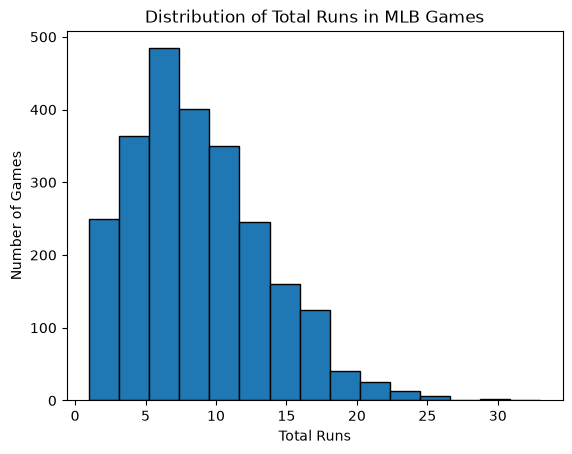

In [36]:
plt.hist(df["total_runs"], bins=15, edgecolor="black")
plt.title("Distribution of Total Runs in MLB Games")
plt.xlabel("Total Runs")
plt.ylabel("Number of Games")
plt.show()

### Total Runs Distribution

I made this graph to see how total runs were spread out across the season. Most games were around the middle of the range, while really high scoring games happened less often. This also shows why using 9 runs as the cutoff makes sense because it is close to the average number of total runs in the dataset.

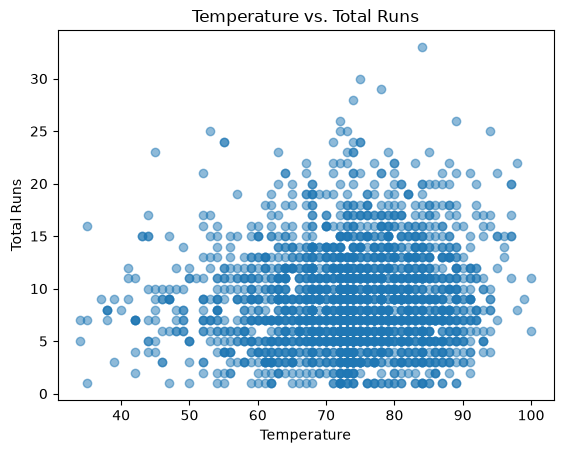

In [37]:
plt.scatter(df["temperature"], df["total_runs"], alpha=0.5)
plt.title("Temperature vs. Total Runs")
plt.xlabel("Temperature")
plt.ylabel("Total Runs")
plt.show()

### Temperature and Total Runs

I also looked at temperature to see if warmer or colder games seemed to have different scoring results. There is a lot of variation, so temperature by itself does not explain the total runs, but it could still help the model when combined with other features.

### Feature Selection

For the model, I only wanted to use information that could be known before the game started. I used the home team, away team, venue, weather, and temperature. I did not use stats like hits, errors, final score, or game length because those happen during or after the game and would give the model information it should not have before making a prediction.

### Data Preparation

Some of my features, like the home team, away team, venue, and weather, are words instead of numbers. I used one hot encoding to turn these categories into a format the models could use. Temperature was already numerical, so I kept it as it was.

In [38]:
features = ["home_team", "away_team", "venue", "weather", "temperature"]

X = df[features]
y = df["runs_9_plus"]

X.head()

,home_team,away_team,venue,weather,temperature
0,Chicago Cubs,Los Angeles Dodgers,Tokyo Dome,Dome,72
1,Chicago Cubs,Los Angeles Dodgers,Tokyo Dome,Dome,72
2,New York Yankees,Milwaukee Brewers,Yankee Stadium,Sunny,48
3,Toronto Blue Jays,Baltimore Orioles,Rogers Centre,Roof Closed,68
4,Texas Rangers,Boston Red Sox,Globe Life Field,Roof Closed,74


In [39]:
print(X.shape)
print(y.shape)

(2464, 5)
(2464,)


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["home_team", "away_team", "venue", "weather"]
numeric_features = ["temperature"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1971, 5)
(493, 5)


### Training and Testing Data

I split the data into 80% training data and 20% testing data. I used the training data to build the models and the testing data to see how they performed on games they had not seen before. I also used `stratify=y` so the amount of 9+ run games and under 9 run games stayed about the same in both groups.

In [41]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.5111561866125761


### Baseline Model

I made a baseline model so I would have something simple to compare my other models to. The baseline always predicts the most common result in the training data. Since the two classes are pretty balanced, the baseline accuracy is around 51%. My real models should do better than this if they are actually learning useful patterns.

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_predictions)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.539553752535497


### Logistic Regression

The first real model I used was logistic regression. I chose it because my target has two possible outcomes, either 9 or more runs or less than 9 runs. I trained the model on the training data and then tested it on games it had not seen before. I compared its accuracy to the baseline to see if it did a better job.

### Logistic Regression Results

The logistic regression model had an accuracy of about 54.0%. This was a little better than the baseline accuracy of 51.1%. The improvement was not very large, but it shows that the features I used had at least some value for predicting whether a game would have 9 or more runs.

In [43]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=5, random_state=42))
])

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_predictions)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.5212981744421906


### Decision Tree

The second model I used was a decision tree. I wanted to compare it with logistic regression because a decision tree can find more complicated patterns in the data. I limited the depth of the tree so it would not become too complicated and overfit the training data.

### Decision Tree Results

The decision tree had an accuracy of about 52.1%. This was a little better than the baseline, but it was not as accurate as logistic regression. Based on accuracy, logistic regression was the better model out of the two.

In [44]:
model_results = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression", "Decision Tree"],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        tree_accuracy
    ]
})

model_results

,Model,Accuracy
0,Baseline,0.511156
1,Logistic Regression,0.539554
2,Decision Tree,0.521298


### Model Comparison

I compared the baseline model, logistic regression, and decision tree using accuracy. Logistic regression had the best accuracy at about 54.0%. The decision tree had about 52.1%, and the baseline had about 51.1%. The models did not beat the baseline by a lot, which shows that predicting whether an MLB game will have 9 or more runs is hard with only these pregame features.

In [45]:
from sklearn.metrics import classification_report, confusion_matrix

print("Logistic Regression Classification Report")
print(classification_report(y_test, logistic_predictions))

print("Confusion Matrix")
print(confusion_matrix(y_test, logistic_predictions))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.55      0.54      0.55       252
           1       0.53      0.54      0.53       241

    accuracy                           0.54       493
   macro avg       0.54      0.54      0.54       493
weighted avg       0.54      0.54      0.54       493

Confusion Matrix
[[137 115]
 [112 129]]


In [46]:
print("Decision Tree Classification Report")
print(classification_report(y_test, tree_predictions))

print("Confusion Matrix")
print(confusion_matrix(y_test, tree_predictions))

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.53      0.57      0.55       252
           1       0.51      0.47      0.49       241

    accuracy                           0.52       493
   macro avg       0.52      0.52      0.52       493
weighted avg       0.52      0.52      0.52       493

Confusion Matrix
[[144 108]
 [128 113]]


### Model Evaluation

I looked at more than just accuracy to compare the models. I also used precision, recall, and F1 score. Precision shows how often a positive prediction was right, recall shows how many of the actual positive games the model found, and F1 score gives a balance between precision and recall.

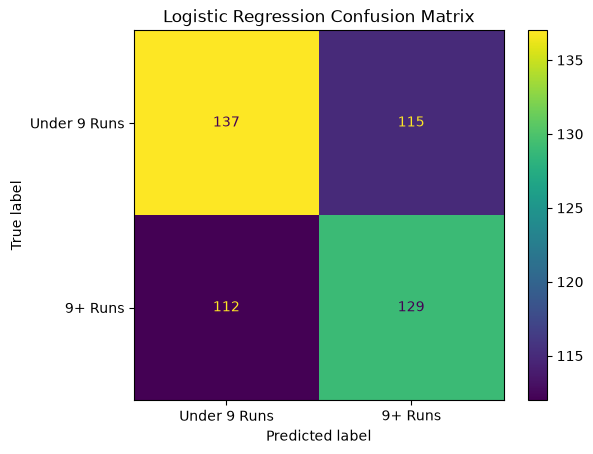

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=["Under 9 Runs", "9+ Runs"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Confusion Matrix

The confusion matrix helped me see exactly what the logistic regression model got right and wrong. It correctly predicted 137 games that finished under 9 runs and 129 games that finished with 9 or more runs. It also made a pretty similar amount of mistakes for both groups, so the model did not seem to strongly favor one result over the other.

### Final Model Selection

Out of the models I tested, logistic regression performed the best. It had an accuracy of about 54.0%, compared to 52.1% for the decision tree and 51.1% for the baseline. I chose logistic regression as my final model because it had the highest accuracy, even though the difference was not very large.

### Limitations and Reflection

One limitation of this model is that it only uses a few pregame features like the teams, venue, weather, and temperature. There are a lot of other things that can affect how many runs are scored, like the starting pitchers, bullpen strength, injuries, and recent team performance. Another limitation is that the data only comes from the 2025 season, so patterns from this season might not be exactly the same in other MLB seasons.

The model also was not very accurate, since the best accuracy was only about 54%. Because of that, I would not use this model by itself to make serious decisions. It shows that predicting total runs is difficult when the model does not have more detailed baseball data. One type of mistake the model can make is a false positive, where it predicts a game will have 9 or more runs but the game actually finishes under 9. A false negative is the opposite, where the model predicts under 9 runs but the game actually has 9 or more. Since the model made both types of mistakes, its predictions should not be treated as guaranteed results.

If I continued this project, I would want to add more pregame stats and compare more models to see if the predictions could improve.

### What I Learned

This project helped me understand how a machine learning project goes from raw data to a final model. I learned how to clean data, choose features, split data into training and testing sets, compare models, and look at more than just accuracy when deciding which model performed best.

### Code and AI Transparency

The code for this project was completed in a Jupyter Notebook using Python. I used pandas for working with the data, matplotlib for graphs, and scikit-learn for the machine learning models.

I used ChatGPT to help explain some coding steps, help with debugging, and help me understand parts of the machine learning process. I reviewed the code and results as I worked through the project.

## References

Koch, B. L. D., & Panorska, A. K. (2013). The impact of temperature on Major League Baseball. *Weather, Climate, and Society, 5*(4), 359–366. https://doi.org/10.1175/WCAS-D-13-00002.1

Major League Baseball. (n.d.). *Statcast park factors*. Baseball Savant. https://baseballsavant.mlb.com/leaderboard/statcast-park-factors

Oler, K. (2025, May 21). The park factors are in the pudding. *FanGraphs Baseball*. https://blogs.fangraphs.com/the-park-factors-are-in-the-pudding/